In [1]:
import cv2
import os
import matplotlib.pyplot as plt

In [4]:
ROOT_DIR = "C:\\Adrianov\\Projects\\Project-Satanael\\"
DEMO_DIR = os.path.join(ROOT_DIR, 'attack_demo')
APRICOT_TEST_DIR = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Images', 'Test')
# TJUDHD_TEST_DIR = os.path.join(ROOT_DIR, 'data', 'tju-dhd', 'patched_random', 'images')
# TJUDHD_LABEL_DIR = os.path.join(ROOT_DIR, 'data', 'tju-dhd', 'patched_random', 'labels')
TJUDHD_TRAIN_DIR = os.path.join(ROOT_DIR, 'data', 'tju-dhd', 'patched_random_bigger', 'images')
TJUDHD_TRAIN_LABEL_DIR = os.path.join(ROOT_DIR, 'data', 'tju-dhd', 'patched_random_bigger', 'labels')
TJUDHD_VAL_DIR = os.path.join(ROOT_DIR, 'data', 'tju-dhd', 'patched_random_bigger_val', 'images')
TJUDHD_VAL_LABEL_DIR = os.path.join(ROOT_DIR, 'data', 'tju-dhd', 'patched_random_bigger_val', 'labels')
TJUDHD_TEST_DIR = os.path.join(ROOT_DIR, 'data', 'tju-dhd', 'patched_random_bigger_test', 'images')
TJUDHD_TEST_LABEL_DIR = os.path.join(ROOT_DIR, 'data', 'tju-dhd', 'patched_random_bigger_test', 'labels')
SEG_RES_DIR = os.path.join(ROOT_DIR, 'results_segment_grey')
MASK_RES_DIR = os.path.join(ROOT_DIR, 'results_mask')
MASK_RES_DIR_CD_APRICOT = os.path.join(ROOT_DIR, 'results_cd_grey_test_APRICOT')
MASK_RES_DIR_ADAPTIVE = os.path.join(ROOT_DIR, 'results_mask_adaptive')
MASK_RES_DIR_CD = os.path.join(ROOT_DIR, 'results_cd_grey')


TJUDHD_TEST_DIR = os.path.join(ROOT_DIR, 'data', 'tju-dhd', 'patched_random_bigger_test', 'images')
TJUDHD_TEST_LABEL_DIR = os.path.join(ROOT_DIR, 'data', 'tju-dhd', 'patched_random_bigger_test', 'labels')
MASK_RES_DIR_PAD = os.path.join(ROOT_DIR, 'pad_res')

## Binary Thresholding at T=0

In [13]:
os.makedirs(MASK_RES_DIR, exist_ok=True)
for filename in os.listdir(SEG_RES_DIR):
    if filename.lower().endswith(("_h_t_o.png")):
        input_path = os.path.join(SEG_RES_DIR, filename)
        
        # Read as grayscale
        img = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Failed to read {input_path}")
            continue
        
        # Apply binary threshold with t = 0
        _, binary_img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY)

        # Save the result
        output_path = os.path.join(MASK_RES_DIR, filename)
        cv2.imwrite(output_path, binary_img)
        print(f"Processed and saved: {output_path}")

Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\1497182366270.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\1497216533789.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\1497216851965.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\1497217395572.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\1497217569982.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\1497217990942.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\1497219384799.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\1497219657784.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\1497220377148.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask\1497228413699.jpg_h_t_o.png


## Binary Thresholding with Adaptive Thresholding

In [11]:
import os
import cv2
import numpy as np

os.makedirs(MASK_RES_DIR_ADAPTIVE, exist_ok=True)
for filename in os.listdir(SEG_RES_DIR):
    if filename.lower().endswith(("_h_t_o.png")):
        input_path = os.path.join(SEG_RES_DIR, filename)
        
        # Read as grayscale
        img = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Failed to read {input_path}")
            continue
        
        # Mask out non-zero pixels
        nonzero_pixels = img[img > 0]
        if nonzero_pixels.size == 0:
            # If no nonzero pixels, just save a zero mask
            binary_img = np.zeros_like(img, dtype=np.uint8)
        else:
            # Compute Otsu threshold only on non-zero pixels
            otsu_thresh, _ = cv2.threshold(nonzero_pixels, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

            # Apply threshold to the original image (keeping zeros as background)
            binary_img = np.where(img > otsu_thresh, 255, 0).astype(np.uint8)
        
        # Save the result
        output_path = os.path.join(MASK_RES_DIR_ADAPTIVE, filename)
        cv2.imwrite(output_path, binary_img)
        print(f"Processed and saved: {output_path}")


Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask_adaptive\1497182366270.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask_adaptive\1497216533789.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask_adaptive\1497216851965.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask_adaptive\1497217395572.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask_adaptive\1497217569982.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask_adaptive\1497217990942.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask_adaptive\1497219384799.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask_adaptive\1497219657784.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask_adaptive\1497220377148.jpg_h_t_o.png
Processed and saved

## Binary Thresholding with Percentile Thresholding

In [60]:
import os
import cv2
import numpy as np

os.makedirs(MASK_RES_DIR_ADAPTIVE, exist_ok=True)
for filename in os.listdir(SEG_RES_DIR):
    if filename.lower().endswith(("_h_t_o.png")):
        input_path = os.path.join(SEG_RES_DIR, filename)
        
        # Read as grayscale
        img = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Failed to read {input_path}")
            continue
        
        # Compute 80th percentile threshold
        thresh_val = np.percentile(img[img > 0], 80)  # ignore zeros if background
        binary_img = np.where(img >= thresh_val, 255, 0).astype(np.uint8)

        # Save the result
        output_path = os.path.join(MASK_RES_DIR_ADAPTIVE, filename)
        cv2.imwrite(output_path, binary_img)
        print(f"Processed and saved: {output_path}")


Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask_adaptive\1497182366270.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask_adaptive\1497216533789.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask_adaptive\1497216851965.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask_adaptive\1497217395572.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask_adaptive\1497217569982.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask_adaptive\1497217990942.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask_adaptive\1497219384799.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask_adaptive\1497219657784.jpg_h_t_o.png
Processed and saved: C:\Adrianov\Projects\Project-Satanael\results_mask_adaptive\1497220377148.jpg_h_t_o.png
Processed and saved

In [61]:
MASKED_DIR = os.path.join(ROOT_DIR, 'masked')

# Ensure output directory exists
os.makedirs(MASKED_DIR, exist_ok=True)

for filename in os.listdir(TJUDHD_TEST_DIR):
    if not filename.lower().endswith((".jpg", ".png", ".jpeg")):
        continue

    # Base name without extension
    name, ext = os.path.splitext(filename)

    # Expected mask filename
    mask_filename = name + ".jpg_h_t_o.png"
    mask_path = os.path.join(MASK_RES_DIR, mask_filename)

    if not os.path.exists(mask_path):
        print(f"Mask not found for {filename}, skipping.")
        continue

    # Load RGB image
    img_path = os.path.join(TJUDHD_TEST_DIR, filename)
    img = cv2.imread(img_path)
    if img is None:
        print(f"Failed to read image: {img_path}")
        continue

    # Load binary mask
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        print(f"Failed to read mask: {mask_path}")
        continue

    # Apply mask: keep only pixels where mask == 255
    masked_img = cv2.bitwise_and(img, img, mask=mask)

    # Save result
    output_path = os.path.join(MASKED_DIR, filename)
    cv2.imwrite(output_path, masked_img)
    print(f"Masked and saved: {output_path}")

Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\1497182366270.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\1497216533789.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\1497216851965.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\1497217395572.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\1497217569982.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\1497217990942.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\1497219384799.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\1497219657784.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\1497220377148.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\1497228413699.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\1497228720438.jpg
Masked and saved: C:\Adrianov\Projects\Project-Satanael\masked\1497229860901.jpg
Masked and saved: C:\Adriano

In [92]:
import os
import cv2
APRICOT_TEST_DIR = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Images', 'test_PAD')
MASK_RES_DIR = os.path.join(ROOT_DIR, 'results_mask')

def resize_all_masks():
    for fname in os.listdir(MASK_RES_DIR):
        if not fname.endswith('.png'):
            continue

        mask_path = os.path.join(MASK_RES_DIR, fname)

        # Extract base image name (e.g., 'frc1_3.jpg') from mask filename
        base_name = fname.split('_h_t_o_c_o')[0]
        original_path = os.path.join(APRICOT_TEST_DIR, base_name)

        # Load the original image to get its size
        original_img = cv2.imread(original_path)
        if original_img is None:
            print(f'[Warning] Original image not found: {original_path}')
            continue

        h, w = original_img.shape[:2]

        # Load the mask (grayscale)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            print(f'[Warning] Could not load mask: {mask_path}')
            continue

        # Resize mask to match original image size
        resized_mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

        # Overwrite original mask with resized version
        cv2.imwrite(mask_path, resized_mask)
        print(f'[Info] Resized and saved: {fname}')


In [93]:
resize_all_masks()

[Info] Resized and saved: frc10_10.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_11.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_12.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_13.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_14.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_15.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_16.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_4.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_6.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_7.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc10_9.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc1_0.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc1_1.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc1_10.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc1_11.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc1_12.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc1_14.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc1_15.jpg_h_t_o_c_o.png
[Info] Resized and saved: frc1_16.jpg_h_t_o_c_o.png
[Info] 

In [40]:
import os
import cv2
import numpy as np

OVERLAY_RES_DIR =  os.path.join(ROOT_DIR, 'results_overlay')

import cv2
import numpy as np
import json

def apply_mask_and_draw_boxes(annotation_path, target_category_id):
    os.makedirs(OVERLAY_RES_DIR, exist_ok=True)

    # Load COCO annotation file
    with open(annotation_path, 'r') as f:
        coco = json.load(f)

    # Build mappings
    from collections import defaultdict
    ann_by_image = defaultdict(list)
    for ann in coco['annotations']:
        ann_by_image[ann['image_id']].append(ann)

    filename_to_id = {img['file_name']: img['id'] for img in coco['images']}

    # Process each image
    for fname in os.listdir(APRICOT_TEST_DIR):
        if not fname.endswith('.jpg'):
            continue

        image_path = os.path.join(APRICOT_TEST_DIR, fname)
        mask_name = fname.replace('.jpg', '.jpg_h_t_o_c_o.png')
        mask_path = os.path.join(MASK_RES_DIR, mask_name)

        if not os.path.exists(mask_path):
            print(f'[Skip] No mask for {fname}')
            continue

        image_id = filename_to_id.get(fname)
        if image_id is None:
            print(f'[Skip] No image entry for {fname}')
            continue

        anns = [a for a in ann_by_image[image_id] if a['category_id'] == target_category_id]
        if not anns:
            print(f'[Skip] No annotations for category {target_category_id} in {fname}')
            continue

        # Load image and mask
        image = cv2.imread(image_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if image is None or mask is None:
            print(f'[Warning] Could not load image or mask for {fname}')
            continue

        if mask.shape != image.shape[:2]:
            mask = cv2.resize(mask, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)

        # Apply mask to image (keep only visible regions)
        masked_image = np.zeros_like(image)
        mask_binary = mask > 0
        masked_image[mask_binary] = image[mask_binary]

        # Draw bounding boxes from original image (regardless of mask)
        for ann in anns:
            x, y, w, h = ann['bbox']
            pt1 = (int(x), int(y))
            pt2 = (int(x + w), int(y + h))
            cv2.rectangle(masked_image, pt1, pt2, color=(0, 255, 0), thickness=2)

        # Save result
        save_path = os.path.join(OVERLAY_RES_DIR, fname)
        cv2.imwrite(save_path, masked_image)
        print(f'[Saved] {save_path}')


In [41]:
annot_path = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Annotations', "coco_apricot_annotations_test.json")
apply_mask_and_draw_boxes(annot_path, 12)

[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_10.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_11.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_12.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_13.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_14.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_15.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_16.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_4.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_6.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_7.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc10_9.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc1_0.jpg
[Saved] C:\Adrianov\Projects\Project-Satanael\results_overlay\frc1_1.jpg
[Saved] C:\Adrianov\Projects\Proj

## Calculate Recall value of Segmentation

In [5]:
import json
import numpy as np
import cv2
import skimage.measure as skms


def get_regions_from_mask(mask, min_area=0):
    """Extract connected regions from a binary mask."""
    label = skms.label(mask)
    props = skms.regionprops(label)
    
    regions = []
    for i, prop in enumerate(props):
        if prop.area >= min_area:
            region_mask = (label == i + 1).astype(np.uint8)
            regions.append({
                'mask': region_mask,
                'bbox': prop.bbox,
                'area': prop.area
            })
    return regions

In [47]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def calculate_iou(region_mask, bbox, bbox_format="coco", epsilon=1e-8, debug=False):
    """
    Compute IoU between a region mask and a bounding box.
    
    Args:
        region_mask (np.ndarray): Binary mask of region (H x W).
        bbox (list/tuple): Bounding box coordinates.
            - COCO format: [x, y, w, h]
            - YOLO format: [x_center, y_center, w, h] (normalized to [0,1])
        bbox_format (str): "coco" or "yolo".
        epsilon (float): Small constant to avoid division by zero.
        debug (bool): If True, visualize the region mask, bbox, and overlaps.
    """
    H, W = region_mask.shape
    
    if bbox_format == "coco":
        x1, y1, w, h = bbox
        x1, y1, x2, y2 = int(x1), int(y1), int(x1 + w), int(y1 + h)

    elif bbox_format == "yolo":
        # YOLO format is normalized: [x_center, y_center, w, h]
        x_center, y_center, w, h = bbox
        x_center, y_center, w, h = x_center * W, y_center * H, w * W, h * H
        x1 = int(x_center - w / 2)
        y1 = int(y_center - h / 2)
        x2 = int(x_center + w / 2)
        y2 = int(y_center + h / 2)

    else:
        raise ValueError("bbox_format must be either 'coco' or 'yolo'")

    # Clip to image boundaries
    if bbox_format == 'yolo':
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(W, x2), min(H, y2)

    bbox_mask = np.zeros_like(region_mask, dtype=np.uint8)
    bbox_mask[y1:y2, x1:x2] = 1

    intersection = np.logical_and(region_mask, bbox_mask).sum()
    union = np.logical_or(region_mask, bbox_mask).sum()
    iou = intersection / (union + epsilon)

    if debug:
        # Prepare visualization
        vis = np.zeros((H, W, 3), dtype=np.uint8)

        # Region mask in red
        vis[region_mask.astype(bool)] = [255, 0, 0]

        # Bbox mask in green
        vis[bbox_mask.astype(bool)] = [0, 255, 0]

        # Intersection in yellow
        intersection_mask = np.logical_and(region_mask, bbox_mask)
        vis[intersection_mask] = [255, 255, 0]

        # Draw bbox rectangle outline
        vis = cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 255, 255), 1)

        plt.figure(figsize=(6,6))
        plt.imshow(vis)
        plt.title(f"IoU = {iou:.4f}")
        plt.axis("off")
        plt.show()

    return iou


In [48]:
def match_region(region_mask, anns, threshold=0.5, mode='coco'):
    """Check if region matches any annotation (IoU ≥ threshold)."""
    for ann in anns:
        iou = calculate_iou(region_mask, ann['bbox'], bbox_format=mode, debug=True)
        # print(iou)
        if iou >= threshold:
            return True
    return False



In [49]:
def tally_true_positive(
    coco_annotation_path, image_filename, category_id, mask, threshold=0.5
):
    """Given an image name and mask, return label (1/0) for each region in the mask."""

    with open(coco_annotation_path, 'r') as f:
        coco = json.load(f)

    image_id = None
    for img in coco['images']:
        if img['file_name'] == image_filename:
            image_id = img['id']
            break

    if image_id is None:
        raise ValueError(f"Image {image_filename} not found in COCO file.")

    anns = [
        ann for ann in coco['annotations']
        if ann['image_id'] == image_id and ann['category_id'] == category_id
    ]
    print(anns)
    regions = get_regions_from_mask(mask)
    tp = 0
    fn = 0
    for ann in anns:
        for r in regions:
            if match_region(r['mask'], [ann], threshold):
                tp += 1
                continue
    if tp == 0:
        fn += 1
    return tp, fn

In [50]:
import os

def tally_tp_yolo(label_dir, image_filename, category_ids, mask, threshold=0.5):
    regions = get_regions_from_mask(mask)
    label_path = os.path.join(label_dir, image_filename + '.txt')
    
    anns = []
    with open(label_path, "r") as f:
        i = 0
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            class_id = int(parts[0])
            if class_id in category_ids:
                x_center, y_center, w, h = map(float, parts[1:5])
                anns.append({
                    'id': i,
                    'bbox': [x_center, y_center, w, h],
                    'category_id': class_id,
                    'area': w * h
                })
                i += 1

    # If there are no ground-truth anns, return zeros (no TP / FN)
    if not anns:
        return 0, 0

    # track which ground-truth anns have been matched (True => TP)
    ann_intersected = {ann['id']: False for ann in anns}

    # small epsilon to detect any overlap (IoU > 0)
    overlap_eps = 1e-6

    for r in regions:
        # collect all bboxes that have any overlap with this region
        intersecting_anns = []
        for ann in anns:
            # use a tiny threshold to detect any overlap
            if match_region(r['mask'], [ann], threshold=overlap_eps, mode='yolo'):
                intersecting_anns.append(ann)

        if not intersecting_anns:
            # nothing to do for this region (no GT bbox touches it)
            continue

        # single intersecting bbox: test with configured threshold
        if len(intersecting_anns) == 1:
            ann = intersecting_anns[0]
            if match_region(r['mask'], [ann], threshold=threshold, mode='yolo'):
                ann_intersected[ann['id']] = True
            # else: leave as False (no match)
        else:
            # multiple intersecting bboxes -> merge and test the merged bbox
            merged_ann = merge_yolo_bboxes(intersecting_anns)
            if match_region(r['mask'], [merged_ann], threshold=threshold, mode='yolo'):
                # mark all intersecting anns as detected
                for ann in intersecting_anns:
                    ann_intersected[ann['id']] = True
            # else: leave them as False (no match)

    tp = sum(1 for v in ann_intersected.values() if v)
    fn = sum(1 for v in ann_intersected.values() if not v)
    return tp, fn


def merge_yolo_bboxes(anns):
    """
    Merge multiple YOLO-format bboxes into a single bbox.
    Each ann['bbox'] is [xc, yc, w, h] (same format you read from labels).
    Returns an ann dict compatible with match_region (same keys as input anns).
    """
    xs = []
    ys = []
    for ann in anns:
        xc, yc, w, h = ann['bbox']
        x1 = xc - w / 2.0
        y1 = yc - h / 2.0
        x2 = xc + w / 2.0
        y2 = yc + h / 2.0
        xs.extend([x1, x2])
        ys.extend([y1, y2])

    x1, x2 = min(xs), max(xs)
    y1, y2 = min(ys), max(ys)

    merged_w = x2 - x1
    merged_h = y2 - y1
    merged_xc = (x1 + x2) / 2.0
    merged_yc = (y1 + y2) / 2.0

    return {
        'bbox': [merged_xc, merged_yc, merged_w, merged_h],
        'category_id': anns[0]['category_id'],
        'area': merged_w * merged_h
    }


# Recall for APRICOT Dataset

### Recall @IoU=0.5

Evaluating images:   0%|                                                                                                 | 0/875 [00:00<?, ?it/s]

[{'area': 584362.6666666669, 'bbox': [1184.89, 1429.33, 760.89, 768.0], 'category_id': 12, 'id': 910000000014, 'image_id': 600014, 'iscrowd': 0, 'angle': [0, 0, 0], 'patch_id': 0, 'is_warped': False}]


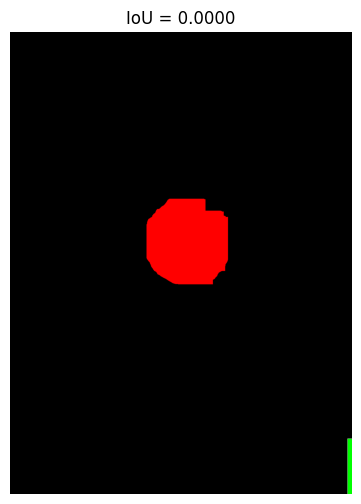

Evaluating images: 100%|█████████████████████████████████████████████████████████████████████████████████████| 875/875 [00:00<00:00, 1335.18it/s]

Undetected adversarial patch @frc1_3.jpg
Final recall score for segmentation method: 0.0%


In [51]:
from tqdm import tqdm
import shutil

tp = 0
fn = 0

os.makedirs('false_negs', exist_ok=True)

for fname in tqdm(os.listdir(APRICOT_TEST_DIR), desc="Evaluating images"):
    if not fname.endswith('frc1_3.jpg'):
        continue
    try:
        mask_path = os.path.join(MASK_RES_DIR_CD_APRICOT, f'{fname}_cd_thresh.png')
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)
    except:
        continue
        
    annot_path = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Annotations', "coco_apricot_annotations_test.json")
    t_tp, t_fn = tally_true_positive(
        coco_annotation_path=annot_path,
        image_filename=fname,
        category_id=12,
        mask=mask,
        threshold=0.5
    )
    if t_fn > 0:
        print(f"Undetected adversarial patch @{fname}")
        # src = os.path.join(ROOT_DIR, 'masked_APRICOT', fname)
        # try:
        #     shutil.copy(src, 'false_negs')
        # except:
        #     pass
    tp += t_tp
    fn += t_fn

print(f"Final recall score for segmentation method: {(tp/(tp+fn))*100}%")

### Recall @IOU=0.40

In [62]:
from tqdm import tqdm

tp = 0
fn = 0

for fname in tqdm(os.listdir(APRICOT_TEST_DIR), desc="Evaluating images"):
    if not fname.endswith('.jpg'):
        continue
    try:
        mask_path = os.path.join(MASK_RES_DIR_APRICOT, f'{fname}_h_t_o_c_o.png')
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)
    except:
        continue
        
    annot_path = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Annotations', "coco_apricot_annotations_test.json")
    t_tp, t_fn = tally_true_positive(
        coco_annotation_path=annot_path,
        image_filename=fname,
        category_id=12,
        mask=mask,
        threshold=0.4
    )
    if t_fn > 0:
        print(f"Undetected adversarial patch @{fname}")
    tp += t_tp
    fn += t_fn

print(f"Final recall score for segmentation method: {(tp/(tp+fn))*100}%")

Evaluating images:   0%|▏                                                                                        | 2/875 [00:00<05:26,  2.67it/s]

Undetected adversarial patch @frc10_10.jpg


Evaluating images:   1%|▉                                                                                        | 9/875 [00:06<09:53,  1.46it/s]

Undetected adversarial patch @frc10_4.jpg


Evaluating images:   1%|█▏                                                                                      | 12/875 [00:08<11:19,  1.27it/s]

...

Undetected adversarial patch @rrs9_9.jpg


Evaluating images:  67%|██████████████████████████████████████████████████████████▌                            | 589/875 [08:16<03:00,  1.58it/s]

Undetected adversarial patch @smc10_0.jpg


Evaluating images: 100%|███████████████████████████████████████████████████████████████████████████████████████| 875/875 [08:23<00:00,  1.74it/s]

Undetected adversarial patch @smc10_3.jpg
Final recall score for segmentation method: 71.42857142857143%


### Recall @IOU=0.35

In [99]:
from tqdm import tqdm

tp = 0
fn = 0

for fname in tqdm(os.listdir(APRICOT_TEST_DIR), desc="Evaluating images"):
    if not fname.endswith('.jpg'):
        continue
    try:
        mask_path = os.path.join(MASK_RES_DIR, f'{fname}_h_t_o_c_o.png')
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)
    except:
        continue
        
    annot_path = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Annotations', "coco_apricot_annotations_test.json")
    t_tp, t_fn = tally_true_positive(
        coco_annotation_path=annot_path,
        image_filename=fname,
        category_id=12,
        mask=mask,
        threshold=0.35
    )
    if t_fn > 0:
        print(f"Undetected adversarial patch @{fname}")
    tp += t_tp
    fn += t_fn

print(f"Final recall score for segmentation method: {(tp/(tp+fn))*100}%")

Evaluating images:   0%|▏                                                                                                        | 2/875 [00:00<06:15,  2.32it/s]

Undetected adversarial patch @frc10_10.jpg


Evaluating images:   1%|█                                                                                                        | 9/875 [00:07<10:58,  1.32it/s]

Undetected adversarial patch @frc10_4.jpg


Evaluating images:   1%|█▍                                                                                                      | 12/875 [00:10<12:12,  1.18it/s]

...

Undetected adversarial patch @sms9_36.jpg


Evaluating images:  99%|█████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 864/875 [15:13<00:10,  1.06it/s]

Undetected adversarial patch @sms9_38.jpg


Evaluating images: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 875/875 [15:22<00:00,  1.05s/it]

Final recall score for segmentation method: 76.51775486827033%


In [108]:
from tqdm import tqdm
import shutil

tp = 0
fn = 0

os.makedirs('false_negs', exist_ok=True)

for fname in tqdm(os.listdir(APRICOT_TEST_DIR), desc="Evaluating images"):
    if not fname.endswith('rrc8_12.jpg'):
        continue
    try:
        mask_path = os.path.join(MASK_RES_DIR_APRICOT, f'{fname}_h_t_o_c_o.png')
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)
    except:
        continue
        
    annot_path = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Annotations', "coco_apricot_annotations_test.json")
    t_tp, t_fn = tally_true_positive(
        coco_annotation_path=annot_path,
        image_filename=fname,
        category_id=12,
        mask=mask,
        threshold=0.2
    )
    if t_fn > 0:
        print(f"Undetected adversarial patch @{fname}")
        src = os.path.join(ROOT_DIR, 'masked_APRICOT', fname)
        try:
            shutil.copy(src, 'false_negs')
        except:
            pass
    tp += t_tp
    fn += t_fn

print(f"Final recall score for segmentation method: {(tp/(tp+fn))*100}%")

Evaluating images:   0%|                                                                                                 | 0/875 [00:00<?, ?it/s]

0.0
0.36242095274428454


Evaluating images: 100%|██████████████████████████████████████████████████████████████████████████████████████| 875/875 [00:01<00:00, 655.24it/s]

0.0
Final recall score for segmentation method: 100.0%


### Recall @IOU=0.25

In [104]:
from tqdm import tqdm
import shutil

tp = 0
fn = 0

os.makedirs('false_negs', exist_ok=True)

for fname in tqdm(os.listdir(APRICOT_TEST_DIR), desc="Evaluating images"):
    if not fname.endswith('.jpg'):
        continue
    try:
        mask_path = os.path.join(MASK_RES_DIR_APRICOT, f'{fname}_h_t_o_c_o.png')
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)
    except:
        continue
        
    annot_path = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Annotations', "coco_apricot_annotations_test.json")
    t_tp, t_fn = tally_true_positive(
        coco_annotation_path=annot_path,
        image_filename=fname,
        category_id=12,
        mask=mask,
        threshold=0.2
    )
    if t_fn > 0:
        print(f"Undetected adversarial patch @{fname}")
        src = os.path.join(ROOT_DIR, 'masked_APRICOT', fname)
        try:
            shutil.copy(src, 'false_negs')
        except:
            pass
    tp += t_tp
    fn += t_fn

print(f"Final recall score for segmentation method: {(tp/(tp+fn))*100}%")

Evaluating images:   0%|▏                                                                                        | 2/875 [00:01<08:41,  1.67it/s]

Undetected adversarial patch @frc10_10.jpg


Evaluating images:   1%|▉                                                                                        | 9/875 [00:10<16:15,  1.13s/it]

Undetected adversarial patch @frc10_4.jpg


Evaluating images:   1%|█▏                                                                                      | 12/875 [00:14<17:56,  1.25s/it]

...

Undetected adversarial patch @sms9_36.jpg


Evaluating images:  99%|█████████████████████████████████████████████████████████████████████████████████████▉ | 864/875 [19:02<00:09,  1.16it/s]

Undetected adversarial patch @sms9_38.jpg


Evaluating images: 100%|███████████████████████████████████████████████████████████████████████████████████████| 875/875 [19:12<00:00,  1.32s/it]

Final recall score for segmentation method: 81.21420389461626%


### Recall @IOU=0.15

In [101]:
from tqdm import tqdm

tp = 0
fn = 0

for fname in tqdm(os.listdir(APRICOT_TEST_DIR), desc="Evaluating images"):
    if not fname.endswith('.jpg'):
        continue
    try:
        mask_path = os.path.join(MASK_RES_DIR, f'{fname}_h_t_o_c_o.png')
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)
    except:
        continue
        
    annot_path = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Annotations', "coco_apricot_annotations_test.json")
    t_tp, t_fn = tally_true_positive(
        coco_annotation_path=annot_path,
        image_filename=fname,
        category_id=12,
        mask=mask,
        threshold=0.15
    )
    if t_fn > 0:
        print(f"Undetected adversarial patch @{fname}")
    tp += t_tp
    fn += t_fn

print(f"Final recall score for segmentation method: {(tp/(tp+fn))*100}%")

Evaluating images:   0%|▏                                                                                                        | 2/875 [00:00<06:59,  2.08it/s]

Undetected adversarial patch @frc10_10.jpg


Evaluating images:   1%|█                                                                                                        | 9/875 [00:08<12:15,  1.18it/s]

Undetected adversarial patch @frc10_4.jpg


Evaluating images:   1%|█▍                                                                                                      | 12/875 [00:11<14:54,  1.04s/it]

...

Undetected adversarial patch @sms9_36.jpg


Evaluating images:  99%|█████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 864/875 [15:15<00:10,  1.06it/s]

Undetected adversarial patch @sms9_38.jpg


Evaluating images: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 875/875 [15:25<00:00,  1.06s/it]

Final recall score for segmentation method: 83.16151202749141%


# Recall for TJU-DHD Dataset

## Recall at IoU=0.5

In [8]:
from tqdm import tqdm

tp = 0
fn = 0

for fname in tqdm(os.listdir(TJUDHD_TEST_DIR), desc="Evaluating images"):
    if not fname.endswith('.jpg'):
        continue
    try:
        mask_path = os.path.join(MASK_RES_DIR_PAD, f'{fname.replace(".jpg", "")}_pad_mask.png')
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)
    except:
        continue
        
    annot_dir = TJUDHD_TEST_LABEL_DIR
    t_tp, t_fn = tally_tp_yolo(
        label_dir=annot_dir,
        image_filename=os.path.splitext(fname)[0],
        category_ids=[1],
        mask=mask,
        threshold=0.5
    )
    if t_fn > 0:
        print(f"Undetected adversarial patch @{fname}")
        try:
            shutil.copy(src, 'false_negs_PAD')
        except:
            pass
    tp += t_tp
    fn += t_fn

print(f"Final recall score for segmentation method: {(tp/(tp+fn))*100}%")

Evaluating images:   1%|█                                                                                                        | 2/204 [00:05<07:48,  2.32s/it]

Undetected adversarial patch @1499563792315.jpg


Evaluating images:   2%|██                                                                                                       | 4/204 [00:05<02:56,  1.13it/s]

Undetected adversarial patch @1499563803890.jpg
Undetected adversarial patch @1499563861719.jpg


Evaluating images:   3%|███                                                                                                      | 6/204 [00:06<01:32,  2.13it/s]

...

Undetected adversarial patch @1502333554745.jpg


Evaluating images:  98%|████████████████████████████████████████████████████████████████████████████████████████████████████▉  | 200/204 [00:59<00:01,  4.00it/s]

Undetected adversarial patch @1502355011539.jpg
Undetected adversarial patch @1502362324066.jpg


Evaluating images: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 204/204 [01:00<00:00,  3.34it/s]

Final recall score for segmentation method: 52.63157894736842%


## Recall @IoU=0.4

In [89]:
from tqdm import tqdm

tp = 0
fn = 0

for fname in tqdm(os.listdir(TJUDHD_TEST_DIR), desc="Evaluating images"):
    if not fname.endswith('.jpg'):
        continue
    try:
        mask_path = os.path.join(MASK_RES_DIR, f'{fname}_h_t_o.png')
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)
    except:
        continue
        
    annot_dir = TJUDHD_LABEL_DIR
    t_tp, t_fn = tally_tp_yolo(
        label_dir=annot_dir,
        image_filename=os.path.splitext(fname)[0],
        category_ids=[1],
        mask=mask,
        threshold=0.4
    )
    if t_fn > 0:
        print(f"Undetected adversarial patch @{fname}")
    tp += t_tp
    fn += t_fn

print(f"Final recall score for segmentation method: {(tp/(tp+fn))*100}%")

Evaluating images:   0%|▏                                                                                        | 2/768 [00:00<02:12,  5.77it/s]

Undetected adversarial patch @1497182366270.jpg


Evaluating images:   2%|█▌                                                                                      | 14/768 [00:01<01:36,  7.81it/s]

Undetected adversarial patch @1497230845643.jpg


Evaluating images:   2%|██                                                                                      | 18/768 [00:02<01:33,  8.02it/s]

...

Undetected adversarial patch @1502430354409.jpg


Evaluating images: 100%|██████████████████████████████████████████████████████████████████████████████████████▊| 766/768 [03:07<00:00,  5.64it/s]

Undetected adversarial patch @1502444829522.jpg


Evaluating images: 100%|███████████████████████████████████████████████████████████████████████████████████████| 768/768 [03:07<00:00,  4.10it/s]

Undetected adversarial patch @1502445857447.jpg
Final recall score for segmentation method: 42.480000000000004%


In [124]:
from tqdm import tqdm

tp = 0
fn = 0

os.makedirs('false_negs_TJUDHD', exist_ok=True)

for fname in tqdm(os.listdir(TJUDHD_TEST_DIR), desc="Evaluating images"):
    if not fname.endswith('.jpg'):
        continue
    try:
        mask_path = os.path.join(MASK_RES_DIR, f'{fname}_h_t_o.png')
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)
    except:
        continue
        
    annot_dir = TJUDHD_TRAIN_LABEL_DIR
    t_tp, t_fn = tally_tp_yolo(
        label_dir=annot_dir,
        image_filename=os.path.splitext(fname)[0],
        category_ids=[1],
        mask=mask,
        threshold=0.3
    )
    if t_fn > 0:
        print(f"Undetected adversarial patch @{fname}")
        src = os.path.join(ROOT_DIR, 'masked', fname)
        try:
            shutil.copy(src, 'false_negs_TJUDHD')
        except:
            pass
    tp += t_tp
    fn += t_fn

print(f"Final recall score for segmentation method: {(tp/(tp+fn))*100}%")

Evaluating images:   0%|                                                                                                 | 0/768 [00:00<?, ?it/s]


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Adrianov\\Projects\\Project-Satanael\\data\\tju-dhd\\patched_random_bigger\\labels\\1497182366270.txt'

In [56]:
from tqdm import tqdm

tp = 0
fn = 0

for fname in tqdm(os.listdir(TJUDHD_TEST_DIR), desc="Evaluating images"):
    if not fname.endswith('.jpg'):
        continue
    try:
        mask_path = os.path.join(MASK_RES_DIR_ADAPTIVE, f'{fname}_h_t_o.png')
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)
    except:
        continue
        
    annot_dir = TJUDHD_LABEL_DIR
    t_tp, t_fn = tally_tp_yolo(
        label_dir=annot_dir,
        image_filename=os.path.splitext(fname)[0],
        category_ids=[1],
        mask=mask,
        threshold=0.2
    )
    if t_fn > 0:
        print(f"Undetected adversarial patch @{fname}")
    tp += t_tp
    fn += t_fn

print(f"Final recall score for segmentation method: {(tp/(tp+fn))*100}%")

Evaluating images:   0%|                                                                                         | 1/768 [00:01<13:28,  1.05s/it]

Undetected adversarial patch @1497182366270.jpg


Evaluating images:   2%|█▉                                                                                      | 17/768 [00:11<07:36,  1.65it/s]

Undetected adversarial patch @1497246410295.jpg


Evaluating images:   3%|██▉                                                                                     | 26/768 [00:15<05:34,  2.22it/s]

...

Undetected adversarial patch @1502362324066.jpg


Evaluating images: 100%|██████████████████████████████████████████████████████████████████████████████████████▉| 767/768 [10:19<00:00,  1.60it/s]

Undetected adversarial patch @1502444829522.jpg


Evaluating images: 100%|███████████████████████████████████████████████████████████████████████████████████████| 768/768 [10:20<00:00,  1.24it/s]

Final recall score for segmentation method: 69.24920127795528%


In [57]:
from tqdm import tqdm

tp = 0
fn = 0

for fname in tqdm(os.listdir(TJUDHD_TEST_DIR), desc="Evaluating images"):
    if not fname.endswith('.jpg'):
        continue
    try:
        mask_path = os.path.join(MASK_RES_DIR_ADAPTIVE, f'{fname}_h_t_o.png')
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)
    except:
        continue
        
    annot_dir = TJUDHD_VAL_LABEL_DIR
    t_tp, t_fn = tally_tp_yolo(
        label_dir=annot_dir,
        image_filename=os.path.splitext(fname)[0],
        category_ids=[1],
        mask=mask,
        threshold=0.15
    )
    if t_fn > 0:
        print(f"Undetected adversarial patch @{fname}")
    tp += t_tp
    fn += t_fn

print(f"Final recall score for segmentation method: {(tp/(tp+fn))*100}%")

Evaluating images:   0%|                                                                                         | 1/768 [00:00<12:14,  1.04it/s]

Undetected adversarial patch @1497182366270.jpg


Evaluating images:   2%|█▉                                                                                      | 17/768 [00:11<07:18,  1.71it/s]

Undetected adversarial patch @1497246410295.jpg


Evaluating images:   3%|██▉                                                                                     | 26/768 [00:15<05:50,  2.12it/s]

...

Undetected adversarial patch @1502333554745.jpg


Evaluating images:  98%|█████████████████████████████████████████████████████████████████████████████████████▌ | 755/768 [09:54<00:09,  1.37it/s]

Undetected adversarial patch @1502362324066.jpg


Evaluating images: 100%|███████████████████████████████████████████████████████████████████████████████████████| 768/768 [10:01<00:00,  1.28it/s]

Final recall score for segmentation method: 72.53184713375796%


## Region's area distribution

In [109]:
from tqdm import tqdm
import cv2

all_areas = []

for fname in tqdm(os.listdir(MASK_RES_DIR), desc="Extracting region info..."):
    if not fname.endswith('.png'):
        continue
    try:
        mask_path = os.path.join(MASK_RES_DIR, fname)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)

        # --- Resize mask so shorter side = 1024 ---
        h, w = mask.shape
        if h < w:
            new_h = 1024
            new_w = int(w * (1024 / h))
        else:
            new_w = 1024
            new_h = int(h * (1024 / w))
        mask = cv2.resize(mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)

    except Exception as e:
        print(f"Error processing {fname}: {e}")
        continue
        
    regions = get_regions_from_mask(mask)
    for r in regions:
        all_areas.append(r['area'])



Extracting region info...: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 873/873 [00:44<00:00, 19.52it/s]


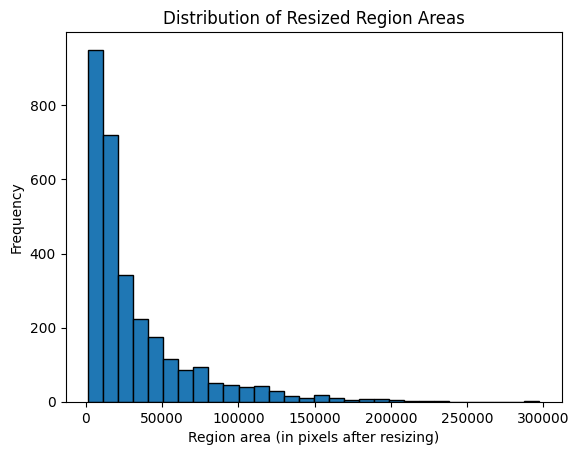

In [110]:
import matplotlib.pyplot as plt

# Plot histogram of resized region areas
plt.hist(all_areas, bins=30, edgecolor='black')
plt.xlabel("Region area (in pixels after resizing)")
plt.ylabel("Frequency")
plt.title("Distribution of Resized Region Areas")
plt.show()

### Feature Extraction

In [1]:
import os

ROOT_DIR = "C:\\Adrianov\\Projects\\Project-Satanael\\"
DEMO_DIR = os.path.join(ROOT_DIR, 'attack_demo')
APRICOT_TEST_DIR = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Images', 'test_PAD')
MASK_RES_DIR = os.path.join(ROOT_DIR, 'results_mask')
ANNOT_PATH = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Annotations', "coco_apricot_annotations_test.json")

In [2]:
import sys
import importlib.util
import warnings

color_path = os.path.abspath("../defenselib/feature_extraction/color.py")

spec = importlib.util.spec_from_file_location("color_ext", color_path)
color_ext = importlib.util.module_from_spec(spec)
sys.modules["color_ext"] = color_ext
spec.loader.exec_module(color_ext)


In [3]:
import sys
import importlib.util
import warnings

texture_path = os.path.abspath("../defenselib/feature_extraction/texture.py")

spec = importlib.util.spec_from_file_location("texture_ext", texture_path)
texture_ext = importlib.util.module_from_spec(spec)
sys.modules["texture_ext"] = texture_ext
spec.loader.exec_module(texture_ext)


In [4]:
import json
import numpy as np
import cv2
import skimage.measure as skms


def get_regions_from_mask(mask, min_area=60):
    """Extract connected regions from a binary mask."""
    label = skms.label(mask)
    props = skms.regionprops(label)
    
    regions = []
    for i, prop in enumerate(props):
        if prop.area >= min_area:
            region_mask = (label == i + 1).astype(np.uint8)
            regions.append({
                'mask': region_mask,
                'bbox': prop.bbox,
                'area': prop.area
            })
    return regions
    
def calculate_iou(region_mask, bbox, epsilon=1e-8):
    """Compute IoU between a region mask and a COCO-style bbox, avoiding division by zero."""
    x1, y1, w, h = bbox
    x1, y1, x2, y2 = int(x1), int(y1), int(x1 + w), int(y1 + h)

    bbox_mask = np.zeros_like(region_mask, dtype=np.uint8)
    bbox_mask[y1:y2, x1:x2] = 1
    intersection = np.logical_and(region_mask, bbox_mask).sum()
    union = np.logical_or(region_mask, bbox_mask).sum()
    # print("Intersection", intersection)
    # print("Union", union)
    return intersection / (union + epsilon)
                          
def match_region(region_mask, anns, threshold=0.5):
    """Check if region matches any annotation (IoU ≥ threshold)."""
    for ann in anns:
        iou = calculate_iou(region_mask, ann['bbox'])
        # print("IoU", iou)
        if iou >= threshold:
            return True
    return False



#### Feature Extraction @IOU=0.5

In [5]:
import skimage.measure as skms
from tqdm import tqdm
import pandas as pd

BINS = 32
THRESHOLD = 0.2
RESIZE = 1024
COL_BINS = True
COL_MOMENTS = True
COL_GLCM = True
COL_GABOR = False
DISTS = [1,2,4,8,16,32,64]
ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]
GABOR_FREQS = [0.1, 0.2, 0.3, 0.4]

with open(ANNOT_PATH, 'r') as f:
    coco = json.load(f)
    
col_names = ["image_name", "region_id", "area"]

if COL_BINS:
    col_names += [f"rgb_R_bin{i}" for i in range(BINS)] + \
                [f"rgb_G_bin{i}" for i in range(BINS)] + \
                [f"rgb_B_bin{i}" for i in range(BINS)] + \
                [f"hsv_H_bin{i}" for i in range(BINS)] + \
                [f"hsv_S_bin{i}" for i in range(BINS)] + \
                [f"hsv_V_bin{i}" for i in range(BINS)]
if COL_MOMENTS:
    col_names += (
        [f"rgb_R_{stat}" for stat in ["mean", "std", "skew"]] +
        [f"rgb_G_{stat}" for stat in ["mean", "std", "skew"]] +
        [f"rgb_B_{stat}" for stat in ["mean", "std", "skew"]] +
        [f"hsv_H_{stat}" for stat in ["mean", "std", "skew"]] +
        [f"hsv_S_{stat}" for stat in ["mean", "std", "skew"]] +
        [f"hsv_V_{stat}" for stat in ["mean", "std", "skew"]]
    )


df_features = pd.DataFrame(columns=col_names)

glcm_extended = False
adv_extended = False
gabor_extended = False

for fname in tqdm(os.listdir(APRICOT_TEST_DIR), desc="Extracting color feature..."):
    if not fname.endswith('.jpg'):
        continue

    image = cv2.imread(os.path.join(APRICOT_TEST_DIR, fname))
    
    h, w = image.shape[:2]
    
    if h < w:
        new_h = RESIZE
        new_w = int(w * (RESIZE / h))
        scale_x = new_w / w
        scale_y = new_h / h
    else:
        new_w = RESIZE
        new_h = int(h * (RESIZE / w))
        scale_x = new_w / w
        scale_y = new_h / h
    
    # --- Resize image ---
    image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    # --- Resize mask ---
    mask_path = os.path.join(MASK_RES_DIR, f'{fname}_h_t_o_c_o.png')
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
    mask = (mask > 0).astype(np.uint8)
    
    # --- Find anns for this image ---
    for img in coco['images']:
        if img['file_name'] == fname:
            image_id = img['id']
            break

    anns = [
        ann for ann in coco['annotations']
        if ann['image_id'] == image_id and ann['category_id'] == 12
    ]
    
    # --- Resize bbox for each annotation ---
    for ann in anns:
        x, y, bw, bh = ann['bbox']
        x *= scale_x
        y *= scale_y
        bw *= scale_x
        bh *= scale_y
        ann['bbox'] = [x, y, bw, bh]        
    regions = get_regions_from_mask(mask)
            
    # print(anns)    
    for ann in anns:
        for r in regions:
            r['adversarial'] = match_region(r['mask'], [ann], THRESHOLD)
    
    feature_list = []
    for region_id, r in enumerate(regions):
        feats = [fname, region_id + 1, r['area']]
    
        if COL_BINS:
            feats.extend(color_ext.extract_color_histograms(image, r['mask'], BINS))
    
        if COL_MOMENTS:
            feats.extend(color_ext.extract_color_moments(image, r['mask']))  

        if COL_GLCM:
            haralick = texture_ext.extract_haralick_features(image, r['mask'], DISTS, ANGLES)
            feats.extend(list(haralick.values()))
            if not glcm_extended:
                col_names.extend(list(haralick.keys()))
                glcm_extended = True
                
        if COL_GABOR:
            gabor_feats = texture_ext.extract_gabor_features(image, r['mask'], GABOR_FREQS, ANGLES)
            feats.extend(list(gabor_feats.values()))
            if not gabor_extended:
                col_names.extend(list(gabor_feats.keys()))
                gabor_extended = True
                
        feats.append(r['adversarial'])
        feature_list.append(feats)

    if not adv_extended:
        col_names += ["adversarial"]
        adv_extended = True
    # print(col_names)
    df = pd.DataFrame(feature_list, columns=col_names)
    df_features = pd.concat([df_features, df], ignore_index=True)


Extracting color feature...:   0%|                                                                                       | 0/875 [00:00<?, ?it/s]C:\Users\adria\AppData\Local\Temp\ipykernel_23976\510971869.py:131: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_features = pd.concat([df_features, df], ignore_index=True)
Extracting color feature...:  21%|████████████████▎                                                            | 186/875 [08:08<24:28,  2.13s/it]C:\Users\adria\AppData\Local\Temp\ipykernel_23976\510971869.py:131: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retai

In [6]:
df_features

,image_name,region_id,area,rgb_R_bin0,rgb_R_bin1,rgb_R_bin2,rgb_R_bin3,rgb_R_bin4,rgb_R_bin5,rgb_R_bin6,...,ASM_dist16_135deg,ASM_dist32_0deg,ASM_dist32_45deg,ASM_dist32_90deg,ASM_dist32_135deg,ASM_dist64_0deg,ASM_dist64_45deg,ASM_dist64_90deg,ASM_dist64_135deg,adversarial
0,frc10_10.jpg,1,8585.0,266,888,911,679,575,540,523,...,0.988562,0.986952,0.986333,0.987689,0.986333,0.982848,0.982891,0.984462,0.982891,False
1,frc10_10.jpg,2,53067.0,3779,4347,3834,3843,3827,3841,3726,...,0.937118,0.931812,0.928507,0.932988,0.930490,0.919895,0.915381,0.921784,0.919026,False
2,frc10_10.jpg,3,37006.0,3644,3842,3334,2970,2986,2884,2696,...,0.957170,0.956586,0.952546,0.952295,0.954621,0.953884,0.947560,0.943642,0.951435,False
3,frc10_11.jpg,1,22900.0,1258,2799,2941,2083,1439,1124,822,...,0.971709,0.968434,0.967519,0.970728,0.967649,0.960845,0.960423,0.965988,0.960601,False
4,frc10_11.jpg,2,12142.0,0,0,1,10,21,54,106,...,0.984336,0.982690,0.981523,0.982965,0.981598,0.978091,0.977044,0.978779,0.977121,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2985,sms9_9.jpg,1,46768.0,0,0,1,19,58,186,316,...,0.926550,0.922013,0.918264,0.922624,0.918301,0.909102,0.903241,0.910556,0.903424,True
2986,sms9_9.jpg,2,6418.0,2,28,119,254,477,577,427,...,0.990050,0.990543,0.989327,0.987960,0.989494,0.990229,0.989279,0.984946,0.989451,False
2987,sms9_9.jpg,3,8260.0,0,0,0,5,16,41,53,...,0.985317,0.983661,0.982385,0.983558,0.982376,0.978813,0.977817,0.978683,0.977808,False
2988,sms9_9.jpg,4,16326.0,0,0,6,47,102,133,196,...,0.974425,0.974376,0.970485,0.969516,0.972326,0.973120,0.965953,0.961929,0.969448,False


In [7]:
df_features["adversarial"].value_counts()

adversarial
False    2281
True      709
Name: count, dtype: int64

In [9]:
OUTPUT_CSV = "features_nogabor_iou20.csv"
df_features.to_csv(OUTPUT_CSV, index=False)
print(f"✅ Saved color features to {OUTPUT_CSV} with {len(df_features)} rows")

✅ Saved color features to features_nogabor_iou20.csv with 2990 rows


### Feature Extraction for TJUDHD

In [9]:
import os

ROOT_DIR = "C:\\Adrianov\\Projects\\Project-Satanael\\"
DEMO_DIR = os.path.join(ROOT_DIR, 'attack_demo')
MASK_RES_DIR = os.path.join(ROOT_DIR, 'results_cd_grey')

TJUDHD_TRAIN_DATA_DIR = os.path.join(ROOT_DIR, 'data', 'tju-dhd', 'patched_random_bigger', 'images')
TJUDHD_TRAIN_LABEL_DIR = os.path.join(ROOT_DIR, 'data', 'tju-dhd', 'patched_random_bigger', 'labels')
TJUDHD_VAL_DATA_DIR = os.path.join(ROOT_DIR, 'data', 'tju-dhd', 'patched_random_bigger_val', 'images')
TJUDHD_VAL_LABEL_DIR = os.path.join(ROOT_DIR, 'data', 'tju-dhd', 'patched_random_bigger_val', 'labels')
TJUDHD_TEST_DATA_DIR = os.path.join(ROOT_DIR, 'data', 'tju-dhd', 'patched_random_bigger_test', 'images')
TJUDHD_TEST_LABEL_DIR = os.path.join(ROOT_DIR, 'data', 'tju-dhd', 'patched_random_bigger_test', 'labels')

In [10]:
import sys
import importlib.util
import warnings

color_path = os.path.abspath("../defenselib/feature_extraction/color.py")

spec = importlib.util.spec_from_file_location("color_ext", color_path)
color_ext = importlib.util.module_from_spec(spec)
sys.modules["color_ext"] = color_ext
spec.loader.exec_module(color_ext)


In [11]:
import sys
import importlib.util
import warnings

texture_path = os.path.abspath("../defenselib/feature_extraction/texture.py")

spec = importlib.util.spec_from_file_location("texture_ext", texture_path)
texture_ext = importlib.util.module_from_spec(spec)
sys.modules["texture_ext"] = texture_ext
spec.loader.exec_module(texture_ext)


In [12]:
import json
import numpy as np
import cv2
import skimage.measure as skms


def calculate_iou(region_mask, bbox, bbox_format="coco", epsilon=1e-8, debug=False):
    """
    Compute IoU between a region mask and a bounding box.
    
    Args:
        region_mask (np.ndarray): Binary mask of region (H x W).
        bbox (list/tuple): Bounding box coordinates.
            - COCO format: [x, y, w, h]
            - YOLO format: [x_center, y_center, w, h] (normalized to [0,1])
        bbox_format (str): "coco" or "yolo".
        epsilon (float): Small constant to avoid division by zero.
        debug (bool): If True, visualize the region mask, bbox, and overlaps.
    """
    H, W = region_mask.shape
    
    if bbox_format == "coco":
        x1, y1, w, h = bbox
        x1, y1, x2, y2 = int(x1), int(y1), int(x1 + w), int(y1 + h)

    elif bbox_format == "yolo":
        # YOLO format is normalized: [x_center, y_center, w, h]
        x_center, y_center, w, h = bbox
        x_center, y_center, w, h = x_center * W, y_center * H, w * W, h * H
        x1 = int(x_center - w / 2)
        y1 = int(y_center - h / 2)
        x2 = int(x_center + w / 2)
        y2 = int(y_center + h / 2)

    else:
        raise ValueError("bbox_format must be either 'coco' or 'yolo'")

    # Clip to image boundaries
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(W, x2), min(H, y2)

    bbox_mask = np.zeros_like(region_mask, dtype=np.uint8)
    bbox_mask[y1:y2, x1:x2] = 1

    intersection = np.logical_and(region_mask, bbox_mask).sum()
    union = np.logical_or(region_mask, bbox_mask).sum()
    iou = intersection / (union + epsilon)

    if debug:
        # Prepare visualization
        vis = np.zeros((H, W, 3), dtype=np.uint8)

        # Region mask in red
        vis[region_mask.astype(bool)] = [255, 0, 0]

        # Bbox mask in green
        vis[bbox_mask.astype(bool)] = [0, 255, 0]

        # Intersection in yellow
        intersection_mask = np.logical_and(region_mask, bbox_mask)
        vis[intersection_mask] = [255, 255, 0]

        # Draw bbox rectangle outline
        vis = cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 255, 255), 1)

        plt.figure(figsize=(6,6))
        plt.imshow(vis)
        plt.title(f"IoU = {iou:.4f}")
        plt.axis("off")
        plt.show()

    return iou


def get_regions_from_mask(mask, min_area=60):
    """Extract connected regions from a binary mask."""
    label = skms.label(mask)
    props = skms.regionprops(label)
    
    regions = []
    for i, prop in enumerate(props):
        if prop.area >= min_area:
            region_mask = (label == i + 1).astype(np.uint8)
            regions.append({
                'mask': region_mask,
                'bbox': prop.bbox,
                'area': prop.area
            })
    return regions

def match_region(region_mask, anns, threshold=0.5, mode='coco'):
    """Check if region matches any annotation (IoU ≥ threshold)."""
    for ann in anns:
        iou = calculate_iou(region_mask, ann['bbox'], bbox_format=mode, debug=False)
        # print(iou)
        if iou >= threshold:
            return True
    return False

def merge_yolo_bboxes(anns):
    """
    Merge multiple YOLO-format bboxes into a single bbox.
    Each ann['bbox'] is [xc, yc, w, h] (same format you read from labels).
    Returns an ann dict compatible with match_region (same keys as input anns).
    """
    xs = []
    ys = []
    for ann in anns:
        xc, yc, w, h = ann['bbox']
        x1 = xc - w / 2.0
        y1 = yc - h / 2.0
        x2 = xc + w / 2.0
        y2 = yc + h / 2.0
        xs.extend([x1, x2])
        ys.extend([y1, y2])

    x1, x2 = min(xs), max(xs)
    y1, y2 = min(ys), max(ys)

    merged_w = x2 - x1
    merged_h = y2 - y1
    merged_xc = (x1 + x2) / 2.0
    merged_yc = (y1 + y2) / 2.0

    return {
        'bbox': [merged_xc, merged_yc, merged_w, merged_h],
        'category_id': anns[0]['category_id'],
        'area': merged_w * merged_h
    }


In [14]:
import skimage.measure as skms
from tqdm import tqdm
import pandas as pd
import time

BINS = 32
THRESHOLD = 0.5
RESIZE = 1024
COL_BINS = True
COL_MOMENTS = True
COL_GLCM = True
COL_GABOR = False
DISTS = [1,2,4,8,16,32,64]
ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]
GABOR_FREQS = [0.1, 0.2, 0.3, 0.4]

annot_dir = TJUDHD_TEST_LABEL_DIR
data_dir = TJUDHD_TEST_DATA_DIR

col_names = ["image_name", "region_id", "area"]

if COL_BINS:
    col_names += [f"rgb_R_bin{i}" for i in range(BINS)] + \
                [f"rgb_G_bin{i}" for i in range(BINS)] + \
                [f"rgb_B_bin{i}" for i in range(BINS)] + \
                [f"hsv_H_bin{i}" for i in range(BINS)] + \
                [f"hsv_S_bin{i}" for i in range(BINS)] + \
                [f"hsv_V_bin{i}" for i in range(BINS)]
if COL_MOMENTS:
    col_names += (
        [f"rgb_R_{stat}" for stat in ["mean", "std", "skew"]] +
        [f"rgb_G_{stat}" for stat in ["mean", "std", "skew"]] +
        [f"rgb_B_{stat}" for stat in ["mean", "std", "skew"]] +
        [f"hsv_H_{stat}" for stat in ["mean", "std", "skew"]] +
        [f"hsv_S_{stat}" for stat in ["mean", "std", "skew"]] +
        [f"hsv_V_{stat}" for stat in ["mean", "std", "skew"]]
    )


df_features = pd.DataFrame(columns=col_names)

glcm_extended = False
adv_extended = False
gabor_extended = False

start = time.time()
i = 0
for fname in tqdm(os.listdir(data_dir), desc="Extracting color feature..."):
    if not fname.endswith('.jpg'):
        continue

    image = cv2.imread(os.path.join(data_dir, fname))
    
    h, w = image.shape[:2]
    
    if h < w:
        new_h = RESIZE
        new_w = int(w * (RESIZE / h))
        scale_x = new_w / w
        scale_y = new_h / h
    else:
        new_w = RESIZE
        new_h = int(h * (RESIZE / w))
        scale_x = new_w / w
        scale_y = new_h / h
    
    # --- Resize image ---
    image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    # --- Resize mask ---
    mask_path = os.path.join(MASK_RES_DIR, f'{fname}_cd_thresh.png')
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
    mask = (mask > 0).astype(np.uint8)
    
    # --- Find ann for this image ---
    label_path = os.path.join(annot_dir, fname.replace(".jpg",".txt"))
    anns = []
    
    category_ids = [1] # Adversarial patch
    
    with open(label_path, "r") as f:
        i = 0
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            class_id = int(parts[0])
            if class_id in category_ids:
                x_center, y_center, w, h = map(float, parts[1:5])
                anns.append({
                    'id': i,
                    'bbox': [x_center, y_center, w, h],
                    'category_id': class_id,
                    'area': w * h
                })
                i += 1
                        
    regions = get_regions_from_mask(mask)
            
    # print(anns) 
    ann_intersected = {ann['id']: False for ann in anns}
    # small epsilon to detect any overlap (IoU > 0)
    overlap_eps = 1e-6
    
    for r in regions:
        intersecting_anns = []
        for ann in anns:
            # use a tiny threshold to detect any overlap
            if match_region(r['mask'], [ann], threshold=overlap_eps, mode='yolo'):
                intersecting_anns.append(ann)

        if not intersecting_anns:
            # nothing to do for this region (no GT bbox touches it)
            r['adversarial'] = False
            continue

        # single intersecting bbox: test with configured threshold
        if len(intersecting_anns) == 1:
            ann = intersecting_anns[0]
            if match_region(r['mask'], [ann], threshold=THRESHOLD, mode='yolo'):
                r['adversarial'] = True
            else:
                r['adversarial'] = False
            # else: leave as False (no match)
        else:
            # multiple intersecting bboxes -> merge and test the merged bbox
            merged_ann = merge_yolo_bboxes(intersecting_anns)
            if match_region(r['mask'], [merged_ann], threshold=THRESHOLD, mode='yolo'):
                # mark all intersecting anns as detected
                r['adversarial'] = True
            else:
                r['adversarial'] = False
            # else: leave them as False (no match)

                
    # for ann in anns:
    #     for r in regions:
    #         r['adversarial'] = match_region(r['mask'], [ann], THRESHOLD)
    
    feature_list = []
    for region_id, r in enumerate(regions):
        feats = [fname, region_id + 1, r['area']]
    
        if COL_BINS:
            feats.extend(color_ext.extract_color_histograms(image, r['mask'], BINS))
    
        if COL_MOMENTS:
            feats.extend(color_ext.extract_color_moments(image, r['mask']))  

        if COL_GLCM:
            haralick = texture_ext.extract_haralick_features(image, r['mask'], DISTS, ANGLES)
            feats.extend(list(haralick.values()))
            if not glcm_extended:
                col_names.extend(list(haralick.keys()))
                glcm_extended = True
                
        if COL_GABOR:
            gabor_feats = texture_ext.extract_gabor_features(image, r['mask'], GABOR_FREQS, ANGLES)
            feats.extend(list(gabor_feats.values()))
            if not gabor_extended:
                col_names.extend(list(gabor_feats.keys()))
                gabor_extended = True
                
        feats.append(r['adversarial'])
        feature_list.append(feats)

    if not adv_extended:
        col_names += ["adversarial"]
        adv_extended = True
    # print(col_names)
    df = pd.DataFrame(feature_list, columns=col_names)
    df_features = pd.concat([df_features, df], ignore_index=True)
    i += 1
    elapsed = time.time() - start

print(f"Feature extracted from {i}. {elapsed:.2f} seconds elasped. Avg extraction time: {(elapsed)/i:.2f}")


Extracting color feature...:   0%|                                                                                                       | 0/204 [00:00<?, ?it/s]C:\Users\adria\AppData\Local\Temp\ipykernel_9724\2707248404.py:173: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_features = pd.concat([df_features, df], ignore_index=True)
Extracting color feature...: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 204/204 [07:32<00:00,  2.22s/it]

Feature extracted from 3. 452.48 seconds elasped. Avg extraction time: 150.83


In [15]:
df_features

,image_name,region_id,area,rgb_R_bin0,rgb_R_bin1,rgb_R_bin2,rgb_R_bin3,rgb_R_bin4,rgb_R_bin5,rgb_R_bin6,...,ASM_dist16_135deg,ASM_dist32_0deg,ASM_dist32_45deg,ASM_dist32_90deg,ASM_dist32_135deg,ASM_dist64_0deg,ASM_dist64_45deg,ASM_dist64_90deg,ASM_dist64_135deg,adversarial
0,1499563559079.jpg,1,38460.0,0,2,60,1142,2901,3389,2615,...,0.942352,0.936604,0.939875,0.943768,0.938059,0.926286,0.935716,0.941181,0.930959,False
1,1499563559079.jpg,2,28268.0,0,68,2063,6707,3521,1749,1193,...,0.957967,0.953286,0.955479,0.959274,0.955661,0.945716,0.951396,0.957932,0.952141,False
2,1499563559079.jpg,3,11420.0,619,164,138,77,67,38,34,...,0.980737,0.978801,0.977419,0.978833,0.977264,0.973716,0.971713,0.973049,0.971589,True
3,1499563792315.jpg,1,48477.0,0,0,2,486,1493,3895,6581,...,0.928150,0.926260,0.925275,0.924460,0.923499,0.919824,0.922494,0.920742,0.918527,False
4,1499563792315.jpg,2,19332.0,0,0,0,10,612,2363,3646,...,0.969689,0.964606,0.967914,0.971276,0.966428,0.955924,0.965345,0.969520,0.961239,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
572,1502362258970.jpg,1,12862.0,533,271,217,202,580,538,406,...,0.978224,0.976579,0.974448,0.975964,0.974455,0.970936,0.968213,0.969592,0.968255,True
573,1502362324066.jpg,1,23141.0,930,451,315,345,315,431,679,...,0.962501,0.960162,0.957117,0.959516,0.957085,0.952304,0.947790,0.950994,0.947824,True
574,1502363047202.jpg,1,57201.0,2818,1270,5415,2836,1314,858,767,...,0.912219,0.911053,0.902746,0.903667,0.903024,0.900774,0.885459,0.885582,0.886024,True
575,1502363077951.jpg,1,54486.0,2607,1225,5279,2987,1283,911,775,...,0.915863,0.914285,0.907301,0.907619,0.906639,0.904379,0.891189,0.889630,0.889694,True


In [175]:
df_features["adversarial"].value_counts()

adversarial
False    399
True     178
Name: count, dtype: int64

In [176]:
OUTPUT_CSV = "features_tjudhd_nogabor_test_inf.csv"
df_features.to_csv(OUTPUT_CSV, index=False)
print(f"✅ Saved color features to {OUTPUT_CSV} with {len(df_features)} rows")

✅ Saved color features to features_tjudhd_nogabor_test.csv with 577 rows
